In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/imtkaggleteam/netflix/NetFlix.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/imtkaggleteam/netflix/NetFlix.csv')

In [3]:
import warnings
warnings.filterwarnings('ignore')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...


In [4]:
# DAP

In [5]:
# data wrangling

#1. Data Gathering
#2. Data Assessing
#3. Data Preprocessing

# Exploratory Analysis

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


remove show_id and description as it is a high cardinality value, will not be be able to help in further analysis

In [7]:
# drop

df.drop(['show_id','description'],axis=1,inplace=True)

In [8]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres'],
      dtype='object')

In [9]:
# overview

df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genres
0,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers"
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies"
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies
4,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV"


In [10]:
# seeking info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          7787 non-null   object
 1   title         7787 non-null   object
 2   director      5398 non-null   object
 3   cast          7069 non-null   object
 4   country       7280 non-null   object
 5   date_added    7777 non-null   object
 6   release_year  7787 non-null   int64 
 7   rating        7780 non-null   object
 8   duration      7787 non-null   int64 
 9   genres        7787 non-null   object
dtypes: int64(2), object(8)
memory usage: 608.5+ KB


### Netflix Dataset Overview

* The dataset contains **7,787 rows and 10 columns** after preprocessing.
* Initially, there were **12 columns**; **`show_id`** and **`description`** were removed due to low analytical relevance.
* It includes **2 numerical features** and **8 categorical (object-type) features**.
* The dataset contains **missing values**, which require appropriate handling through imputation or removal.
* The high proportion of categorical variables indicates the need for **encoding techniques** during further analysis or modeling.

### One-line Summary

The dataset is moderately sized, predominantly categorical, and requires preprocessing to handle missing values and prepare it for analysis.


In [11]:
# seeking description

df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


### Additional Insights

* The **release year** ranges from **1925 to 2021**, indicating that Netflix hosts content spanning several decades.

* However, the absence of records beyond 2021 suggests **data inconsistency or outdated data collection**, as the current year is 2026.

* The **duration column** ranges from **1 to 312**, which reflects mixed data types:

  * **Movies** are represented in minutes
  * **TV Shows** are represented in number of seasons

* This indicates that the duration feature is **not standardized** and may require **separation or transformation** for accurate analysis.


In [12]:
# completeness
df.isnull().sum()[df.isnull().sum()>0]

director      2389
cast           718
country        507
date_added      10
rating           7
dtype: int64

In [13]:
df.isnull().mean()[df.isnull().mean()>0]*100 # percentage of null values

director      30.679337
cast           9.220496
country        6.510851
date_added     0.128419
rating         0.089893
dtype: float64

In [14]:
# placeholder --> unknown

df.director.mode()

0    Raúl Campos, Jan Suter
Name: director, dtype: object

In [15]:
import warnings
warnings.filterwarnings('ignore')

df.director.fillna('unknown',inplace=True)
df.isnull().mean()[df.isnull().mean()>0]*100

cast          9.220496
country       6.510851
date_added    0.128419
rating        0.089893
dtype: float64

In [16]:
print(df.country.mode().values)
df.country.fillna('United States',inplace=True)

['United States']


In [17]:
df.isnull().mean()[df.isnull().mean()>0]*100

cast          9.220496
date_added    0.128419
rating        0.089893
dtype: float64

In [18]:
# dropna

df.dropna(inplace=True)
print('percentage of null values',df.isnull().mean()[df.isnull().mean()>0]*100)

percentage of null values Series([], dtype: float64)


In [19]:
# duplicates

df.duplicated().sum()

np.int64(0)

In [20]:
# exploratory analysis

df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres'],
      dtype='object')

In [21]:
# univariate analysis

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
temp = df.type.value_counts().reset_index()

px.pie(temp,values='count',names='type',hole=.5,height=400,title='Distribution of type of content on Netflix',color_discrete_sequence=['#8C0A12','#1B3A6F']).show()
temp

,type,count
0,Movie,4946
1,TV Show,2106


* Approximately **70% of the content consists of movies**, while the remaining **30% comprises TV series**.

* This distribution clearly indicates that **Netflix’s content library is heavily dominated by movies**.

* It suggests that the platform primarily focuses on **movie-based content consumption**, with comparatively fewer TV shows available.

* The imbalance may reflect **user demand trends**, where movies are more frequently consumed or easier to distribute globally.

* From a data perspective, this also highlights a **content skew**, which should be considered during analysis or modeling to avoid biased insights.


In [22]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres'],
      dtype='object')

In [23]:
df.release_year.describe()

count    7052.000000
mean     2013.750709
std         8.629779
min      1942.000000
25%      2013.000000
50%      2017.000000
75%      2018.000000
max      2021.000000
Name: release_year, dtype: float64

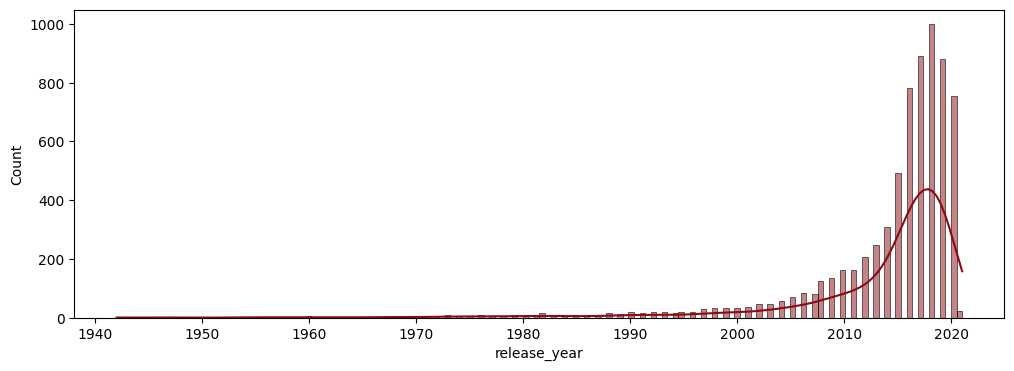

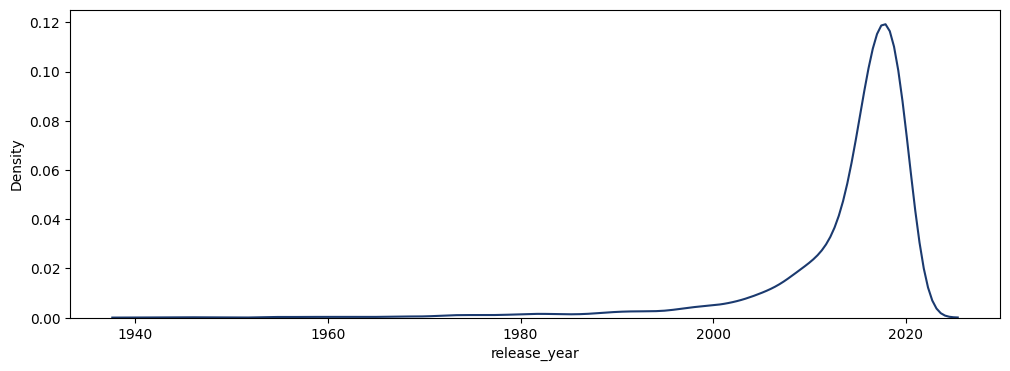

skewness  -3.2299826566664893


In [24]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='release_year',kde=True,color='#8C0A12')
plt.show()
plt.figure(figsize=(12,4))
sns.kdeplot(data=df,x='release_year',color='#1B3A6F')
plt.show()

print('skewness ',df.release_year.skew())

* The **distribution of release years is negatively skewed (left-skewed)**, indicating that a large proportion of movies were released in more recent years.

* This suggests that **most of the content in the dataset has been produced after the year 2000**, reflecting the expansion of the film industry and digital distribution.

* The growth can be attributed to factors such as **advancements in technology, increased accessibility to storage media (e.g., DVDs and CDs), and the rise of global streaming platforms**.

* A noticeable **decline in movie releases is observed after 2020**, which can be linked to the impact of the **COVID-19 pandemic**, where production and theatrical releases were significantly disrupted.

* Overall, the trend highlights how **external factors like technological evolution and global events influence content production patterns**.


In [25]:
df.date_added.str.split('-',expand=True)

,0,1,2
0,14,Aug,20
1,15,Dec,17
2,5,Jan,19
3,1,Mar,16
4,3,Dec,18
...,...,...,...
7781,1,Oct,19
7783,1,Sep,20
7784,26,Aug,16
7785,8,Mar,19


In [26]:
temp_date = df.date_added.str.split('-',expand=True)[[2]].value_counts().sort_index().reset_index()

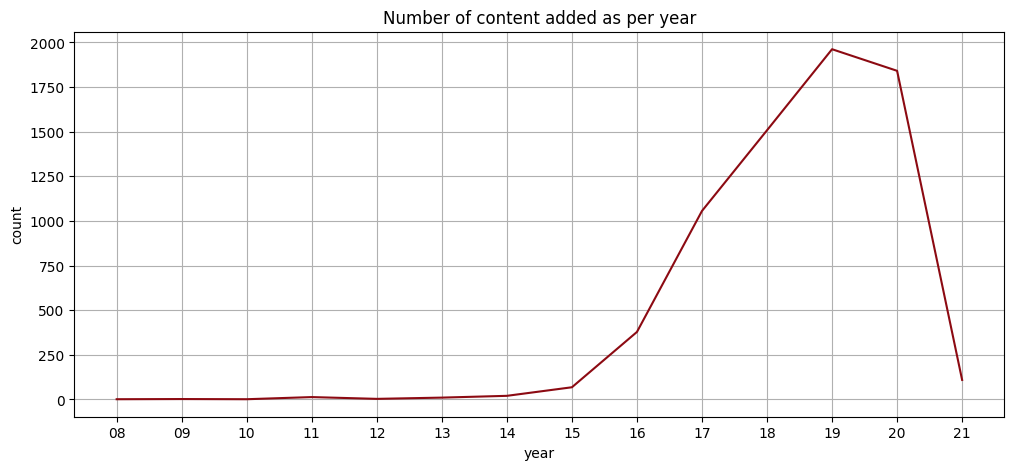

------------------------------------------------------------------------------------------------------------------


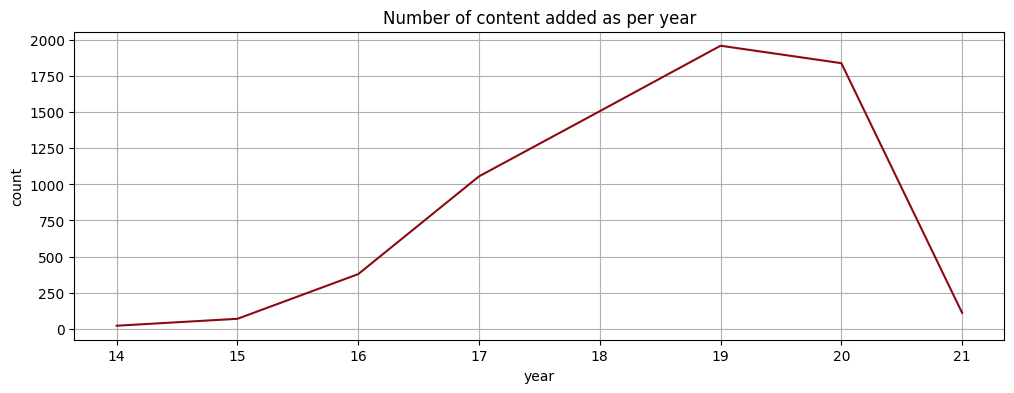

In [27]:
temp_date.columns=['year','count']
temp_date
plt.figure(figsize=(12,5))
sns.lineplot(data=temp_date,x='year',y='count',color='#8C0A12')
plt.title('Number of content added as per year')
plt.grid()
plt.show()
print('-'*114)
plt.figure(figsize=(12,4))
sns.lineplot(data=temp_date.tail(8),x='year',y='count',color='#8C0A12')
plt.title('Number of content added as per year')
plt.grid()
plt.show()

* Netflix began its journey as an online streaming platform in **2007**, marking the start of digital content distribution.

* From **2008 to 2014**, the volume of content added each year remained relatively low, indicating a **slow expansion phase** of the platform.

* After **2014**, there is a significant and consistent increase in content additions, reflecting Netflix’s **aggressive growth strategy**.

* This surge can be attributed to factors such as **reduced internet costs, wider global internet accessibility, and increased adoption of streaming services**.

* The platform appears to reach its **peak content addition around 2019–2020**, highlighting a period of maximum expansion.

* A noticeable **decline is observed in 2020 and 2021**, which can be linked to the **COVID-19 pandemic**, as production and release schedules were disrupted globally.

* Overall, the trend demonstrates how **technological advancements and external global events directly influence content availability on streaming platforms**.

In [28]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres'],
      dtype='object')

In [29]:
temp_country = df.country.value_counts().head(15).reset_index()
df.country.value_counts().head(15).reset_index()

,country,count
0,United States,2651
1,India,894
2,United Kingdom,331
3,Japan,220
4,South Korea,180
5,Canada,159
6,Spain,117
7,Egypt,100
8,Turkey,100
9,France,99


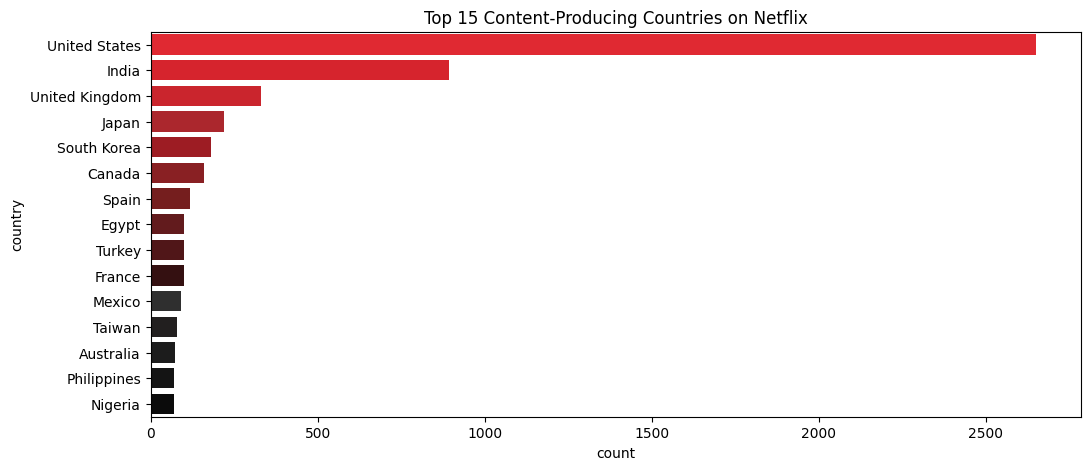

In [30]:
plt.figure(figsize=(12,5))
colors = [
    "#FF0A16", "#F40612", "#E50914", "#C11119", "#B20710",
    "#9B0E13", "#831010", "#6E0F12", "#5A0C0F", "#3A0A0C", 
    "#2F2F2F", "#221F1F", "#1C1C1C", "#141414", "#0B0B0B"
]
sns.countplot(
    data=df,
    y='country',
    order=temp_country.country,
    palette=colors
)
plt.title('Top 15 Content-Producing Countries on Netflix')
plt.show()

* The **majority of content originates from the United States**, indicating that Netflix’s library is heavily influenced by Hollywood and US-based productions.

* The **second-largest contribution comes from India**, which is notable given that Netflix entered the Indian market **approximately 9 years after its initial launch in the US**. Despite the late entry, India has rapidly become a significant content source.

* Following India, there is a **sharp drop in content contribution from other countries**, such as the United Kingdom, Japan, and South Korea.

* Although **Japan and South Korea are globally recognized for anime and drama content**, their representation in the dataset is comparatively low.

* This suggests a **potential underrepresentation of regional content** or a selective acquisition strategy by Netflix, despite strong global demand for content from these countries.

* Overall, the distribution highlights a **strong geographical imbalance**, with the US dominating, emerging markets like India growing तेजी, and other content-rich regions contributing relatively less.


In [31]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres'],
      dtype='object')

In [32]:
df.director.value_counts()

director
unknown                          2077
Raúl Campos, Jan Suter             18
Marcus Raboy                       16
Jay Karas                          14
Cathy Garcia-Molina                13
                                 ... 
Elvira Lind                         1
Jay Surridge                        1
Jeremy Kenyon Lockyer Corbell       1
Rohan Sippy                         1
Lev L. Spiro                        1
Name: count, Length: 3710, dtype: int64

In [33]:
df.cast

0       João Miguel, Bianca Comparato, Michel Gomes, R...
1       Rajneesh Duggal, Adah Sharma, Indraneil Sengup...
2       Reza Rahadian, Bunga Citra Lestari, Tara Basro...
3       Alan Ritchson, Darin Brooks, James Cade, Rob R...
4                                      David Attenborough
                              ...                        
7781    Johnny Depp, Penélope Cruz, Franka Potente, Ra...
7783    Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...
7784    Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...
7785    Cate Blanchett, Sally Hawkins, Alec Baldwin, L...
7786             Sarah Paulson, Mark Duplass, Clu Gulager
Name: cast, Length: 7052, dtype: object

(7052, 50)
max number of actors in a movie  50


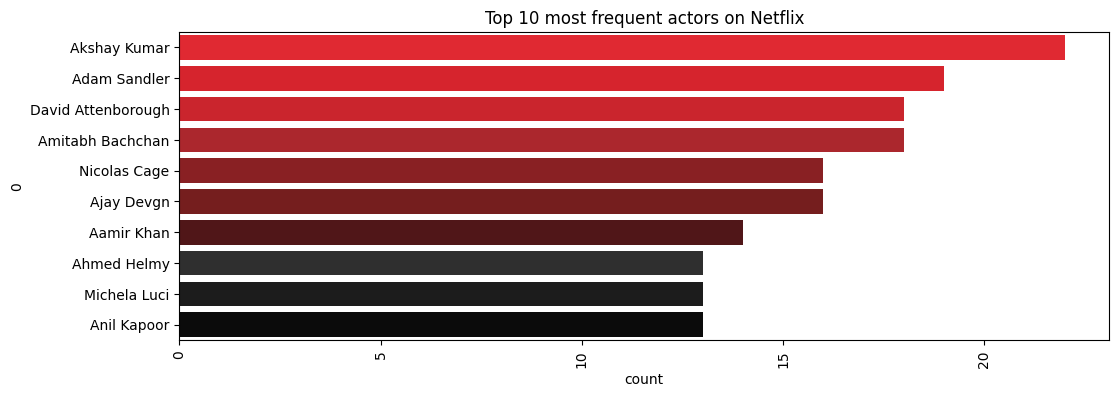

In [34]:
print(df.cast.str.split(',',expand=True).shape)
print('max number of actors in a movie ',df.cast.str.split(',',expand=True).shape[1])
temp_cast = df.cast.str.split(',',expand=True)[[0]].value_counts().head(11).reset_index().iloc[1:11]
colors = ["#FF0A16", "#F40612", "#E50914", "#C11119", "#9B0E13", "#831010", "#5A0C0F", "#2F2F2F", "#1C1C1C", "#0B0B0B"]
plt.figure(figsize=(12,4))
sns.barplot(data=temp_cast,y=0,x='count',palette=colors)
plt.title('Top 10 most frequent actors on Netflix')
plt.xticks(rotation=90)
plt.show()


* Some movies in the dataset have **large ensemble casts, with up to 50 actors**, indicating the presence of multi-starrer or highly collaborative productions.

* In terms of actor frequency, **Shah Rukh Khan** has the highest number of appearances, followed by **Akshay Kumar**, making them the most prominent actors in the dataset.

* **Adam Sandler** ranks third, highlighting Netflix’s strong association with his films, while **David Attenborough** appears fourth, primarily due to documentary content.

* A significant number of actors in the top list are from India, including **Amitabh Bachchan**, **Ajay Devgn**, and **Aamir Khan**.

* This trend indicates that **Indian actors dominate the frequency distribution**, suggesting a strong presence of Indian content on Netflix.

* Overall, the pattern reflects that **India is a key and growing market for Netflix**, both in terms of content production and audience demand.

In [35]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres'],
      dtype='object')

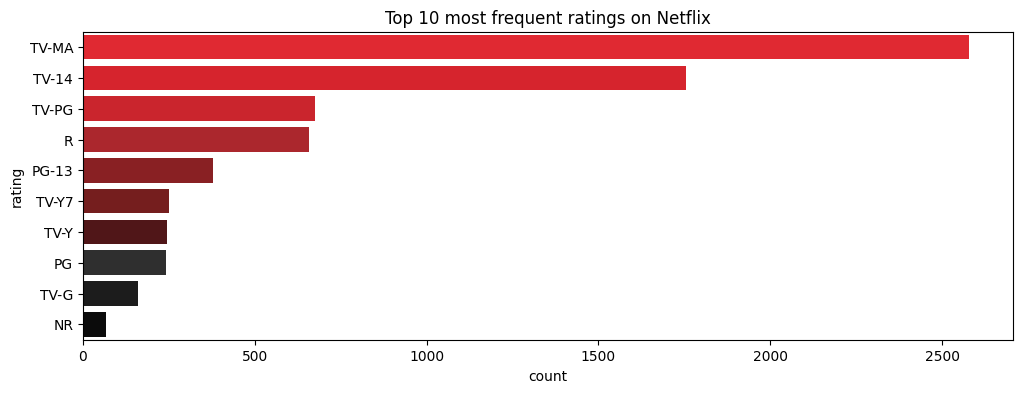

In [36]:
temp_rating = df.rating.value_counts().head(10).reset_index()
colors = ["#FF0A16", "#F40612", "#E50914", "#C11119", "#9B0E13", "#831010", "#5A0C0F", "#2F2F2F", "#1C1C1C", "#0B0B0B"]
plt.figure(figsize=(12,4))
sns.barplot(data=temp_rating,x='count',y='rating',palette=colors)
plt.title('Top 10 most frequent ratings on Netflix')
plt.show()

* The **TV-MA rating has the highest number of listings**, indicating that mature content is the most prominently available and likely the most consumed on Netflix.

* This suggests that **adult audiences form a major segment of the platform’s user base**, driving demand for mature and diverse storytelling.

* The **TV-14 category ranks second**, highlighting that **teenagers and young adults are also highly active users** on Netflix.

* The presence of **TV-PG content in the third position** reflects that **family-friendly and child-appropriate content is also significant**, though comparatively lower than mature content.

* Overall, the rating distribution indicates that Netflix primarily caters to **teenagers and adults**, while still maintaining a **balanced offering for younger audiences**.

In [37]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres'],
      dtype='object')

In [38]:
df.duration
df.type

movie = df.query('type=="Movie"')
show1 = df.query('type=="TV Show"')

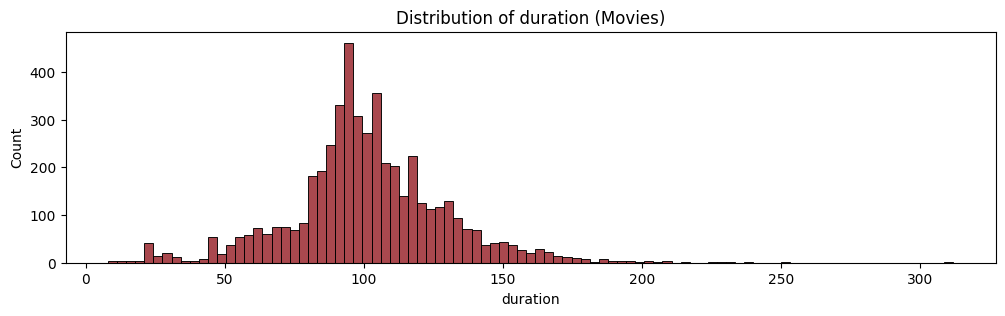

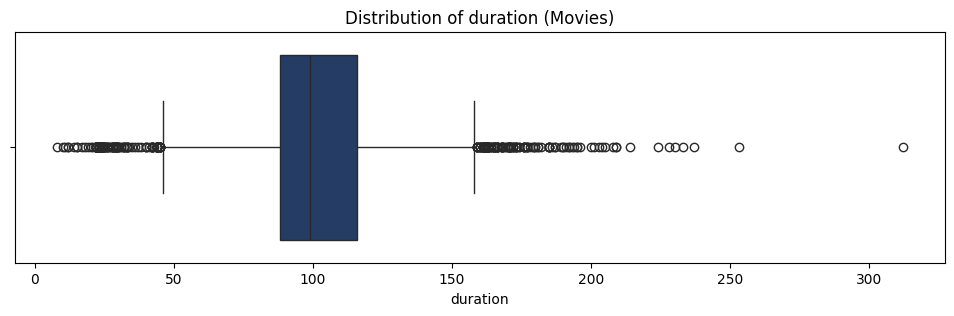

------------------------------------------------------------------------------------------------------------------


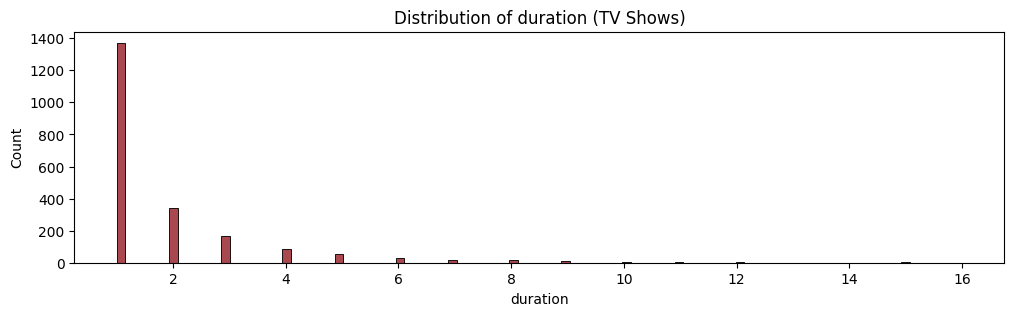

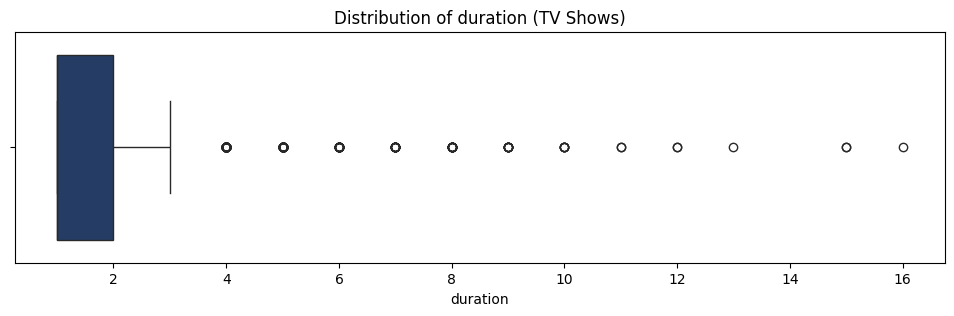

In [39]:
L1 = ['#8C0A12', '#1B3A6F']

plt.figure(figsize=(12,3))
sns.histplot(data=movie,x='duration',color=L1[0])
plt.title('Distribution of duration (Movies)')
plt.show()
plt.figure(figsize=(12,3))
sns.boxplot(data=movie,x='duration',color=L1[1])
plt.title('Distribution of duration (Movies)')
plt.show()

print('-'*114)

plt.figure(figsize=(12,3))
sns.histplot(data=show1,x='duration',color=L1[0])
plt.title('Distribution of duration (TV Shows)')
plt.show()
plt.figure(figsize=(12,3))
sns.boxplot(data=show1,x='duration',color=L1[1])
plt.title('Distribution of duration (TV Shows)')
plt.show()

* The **distribution of movie durations is slightly right-skewed**, indicating that most movies have shorter to moderate runtimes, with fewer movies having very long durations.

* The **majority of movies fall within the range of 80 to 120 minutes**, suggesting this is the standard and most preferred duration for films on Netflix.

* The boxplot shows the presence of **outliers on both ends**, with some movies having extremely short durations and others exceeding **200–300 minutes**, representing special or extended content.

* The **median duration is close to ~100 minutes**, reinforcing that most content is centered around a typical feature-length format.

* For **TV series**, the distribution is highly **right-skewed**, with the majority having **only 1–2 seasons**, indicating that short-series formats are more common.

* As the number of seasons increases, the count drops significantly, showing that **long-running series (8+ seasons) are relatively rare**.

* The **median duration is close to ~100 minutes**, reinforcing that most content is centered around a typical feature-length format.

* For **TV series**, the distribution is highly **right-skewed**, with the majority having **only 1–2 seasons**, indicating that short-series formats are more common.

* As the number of seasons increases, the count drops significantly, showing that **long-running series (8+ seasons) are relatively rare**.

* The boxplot for TV series highlights **many outliers on the higher end**, meaning a few shows have significantly more seasons compared to the majority.

* Overall, Netflix content suggests a preference for **moderate-length movies and shorter TV series**, aligning with modern audience attention spans and binge-watching behavior.

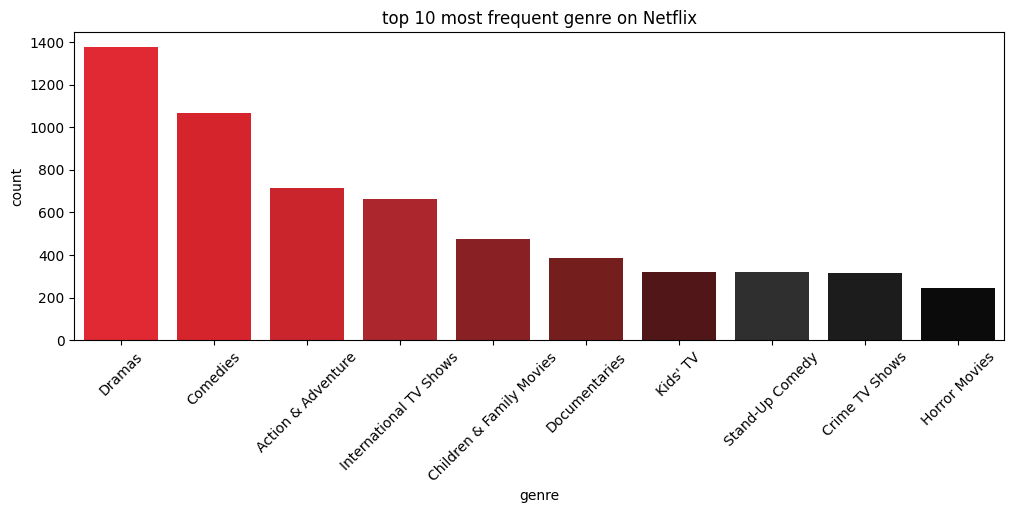

,genre,count
0,Dramas,1377
1,Comedies,1068
2,Action & Adventure,715
3,International TV Shows,665
4,Children & Family Movies,475
5,Documentaries,386
6,Kids' TV,322
7,Stand-Up Comedy,320
8,Crime TV Shows,314
9,Horror Movies,244


In [40]:
df.columns
temp_genre = df.genres.str.split(',',expand=True)[[0]].value_counts().sort_values(ascending=False).head(10).reset_index()
temp_genre.columns = ['genre','count']

colors = ["#FF0A16", "#F40612", "#E50914", "#C11119", "#9B0E13", "#831010", "#5A0C0F", "#2F2F2F", "#1C1C1C", "#0B0B0B"]
plt.figure(figsize=(12,4))
sns.barplot(data=temp_genre,x='genre',y='count',palette=colors)
plt.title('top 10 most frequent genre on Netflix')
plt.xticks(rotation=45)
plt.show()

temp_genre

* **Dramas dominate**, showing strong preference for story-based content.
* **Comedies are second**, indicating high demand for light entertainment.
* **Documentaries & Action** have solid presence, reflecting diverse viewer interests.
* **International TV shows are high**, highlighting Netflix’s global expansion.
* **Kids & family content is moderate**, not the primary focus.
* **Crime & stand-up comedy** serve niche but consistent audiences.
* **Horror is least**, showing limited but specific demand.
